# Fusion_ResNet_TFIDF_get_report_metrics.ipynb

## Mục tiêu
Notebook này dùng để chạy phương pháp **ResNet50 + TF-IDF + pHash Boost + Candidate Reranking** và xuất ra bảng số liệu dùng trực tiếp cho báo cáo.

Cấu hình đang dùng:

```text
alpha = 0.76
pHash config = strong
candidate_k = 100
K_LIST = [1, 3, 5, 10]
```

Sau khi chạy xong, lấy bảng ở cell cuối:

```text
REPORT_metric_comparison_table.csv
REPORT_metric_comparison_table.xlsx
FINAL_new_method_report_row.csv
```

pip install openpyxl

## CELL 1: Import thư viện

In [81]:
# Nếu chạy Colab mà thiếu FAISS, mở comment dòng dưới:
# !pip install faiss-cpu -q

import os
import re
import time
import random
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image, UnidentifiedImageError

import faiss
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('✅ Import xong')
print('PyTorch:', torch.__version__)
print('FAISS  :', faiss.__version__)
print('Device :', DEVICE)

✅ Import xong
PyTorch: 2.12.0+cu126
FAISS  : 1.13.2
Device : cuda


## CELL 2: Cấu hình đường dẫn

Chỉ cần sửa `DATA_DIR` cho đúng máy. Các file cache sẽ nằm trong `../data/processed/` và kết quả nằm trong `../results/`.

In [82]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ SỬA DATA_DIR CHO ĐÚNG VỚI MÁY ĐANG CHẠY                                ║
# ╚══════════════════════════════════════════════════════════════════════════╝
DATA_DIR = r'E:\study\DoAnPython\project\data\raw'

CSV_PATH  = os.path.join(DATA_DIR, 'train.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'train_images')

PROCESSED = '../data/processed/'
RESULTS   = '../results/'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

# Chạy full dataset để báo cáo đẹp hơn. Nếu máy yếu, đổi SAMPLE_GROUPS = 250 để test nhanh.
SAMPLE_GROUPS = None       # None = full dataset; ví dụ 250 = lấy 250 nhóm, mỗi nhóm tối đa 2 ảnh
MAX_PER_GROUP = None       # None = giữ toàn bộ ảnh mỗi nhóm; ví dụ 2 = mỗi nhóm lấy 2 ảnh

BATCH_SIZE = 32
NUM_WORKERS = 0

TFIDF_MAX_FEATURES = 5000

# Cấu hình candidate reranking tốt nhất hiện tại
TOP_CANDIDATES = 100       # lấy top100 từ image và top100 từ text rồi union để rerank
K_LIST = [1, 3, 5, 10]
MAX_K = max(K_LIST)

# Cấu hình final đã chọn sau thực nghiệm
BEST_ALPHA = 0.76
BEST_PHASH_CONFIG = {
    "name": "strong",
    "same": 0.10,   # pHash giống hệt
    "near5": 0.06,  # Hamming distance <= 5
    "near10": 0.03  # Hamming distance <= 10
}

FINAL_METHOD_NAME = "ResNet50_TFIDF_pHash_strong_alpha_0.76"

print('Kiểm tra đường dẫn:')
for p in [CSV_PATH, IMAGE_DIR]:
    print(('✅' if os.path.exists(p) else '❌'), p)

print('\nCấu hình final:')
print('BEST_ALPHA       =', BEST_ALPHA)
print('BEST_PHASH_CONFIG=', BEST_PHASH_CONFIG)
print('TOP_CANDIDATES   =', TOP_CANDIDATES)


Kiểm tra đường dẫn:
✅ E:\study\DoAnPython\project\data\raw\train.csv
✅ E:\study\DoAnPython\project\data\raw\train_images

Cấu hình final:
BEST_ALPHA       = 0.76
BEST_PHASH_CONFIG= {'name': 'strong', 'same': 0.1, 'near5': 0.06, 'near10': 0.03}
TOP_CANDIDATES   = 100


## CELL 3: Đọc dữ liệu và tạo candidate_df

- Mặc định dùng toàn bộ dataset có `label_group` từ 2 ảnh trở lên.
- Nếu máy yếu, đặt `SAMPLE_GROUPS = 250`, `MAX_PER_GROUP = 2` ở Cell 2 để chạy thử nhanh.

In [83]:
df = pd.read_csv(CSV_PATH)

# Chỉ giữ nhóm có ít nhất 2 ảnh, vì query phải có đáp án trong gallery.
label_counts_full = df['label_group'].value_counts()
valid_groups = label_counts_full[label_counts_full >= 2].index
df_valid = df[df['label_group'].isin(valid_groups)].copy()

if SAMPLE_GROUPS is not None:
    chosen_groups = pd.Series(df_valid['label_group'].unique()).sample(
        n=min(SAMPLE_GROUPS, df_valid['label_group'].nunique()),
        random_state=SEED
    ).tolist()
    df_valid = df_valid[df_valid['label_group'].isin(chosen_groups)].copy()

if MAX_PER_GROUP is not None:
    df_valid = (
        df_valid.groupby('label_group', group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), MAX_PER_GROUP), random_state=SEED))
        .reset_index(drop=True)
    )

candidate_df = df_valid.sample(frac=1, random_state=SEED).reset_index(drop=True)
candidate_df['image_path'] = candidate_df['image'].apply(lambda x: os.path.join(IMAGE_DIR, x))

CANDIDATE_PATH = os.path.join(PROCESSED, 'candidate_df_resnet_tfidf_fusion.csv')
candidate_df.to_csv(CANDIDATE_PATH, index=False)

labels = candidate_df['label_group'].values
label_counter = Counter(labels)

print(f'✅ candidate_df: {len(candidate_df):,} ảnh')
print(f'✅ Số nhóm     : {candidate_df["label_group"].nunique():,}')
print(f'✅ Nhóm nhỏ nhất: {candidate_df["label_group"].value_counts().min()} ảnh')
print(f'✅ Đã lưu: {CANDIDATE_PATH}')


# pHash dùng để boost các ảnh gần trùng trong bước reranking.
# Shopee image_phash là chuỗi hex 64-bit. Convert sang int để tính Hamming distance nhanh hơn.
phashes = candidate_df['image_phash'].astype(str).values

def phash_to_uint64(x):
    try:
        return np.uint64(int(str(x), 16))
    except Exception:
        return np.uint64(0)

phash_ints = np.array([phash_to_uint64(x) for x in phashes], dtype=np.uint64)

def phash_hamming_many(query_idx, cand_indices):
    """Trả về Hamming distance giữa pHash của query và danh sách candidate."""
    q = int(phash_ints[query_idx])
    return np.array([(q ^ int(phash_ints[j])).bit_count() for j in cand_indices], dtype=np.int16)

print('✅ Đã chuẩn bị pHash để boost:', len(phash_ints))


candidate_df.head(3)

✅ candidate_df: 34,250 ảnh
✅ Số nhóm     : 11,014
✅ Nhóm nhỏ nhất: 2 ảnh
✅ Đã lưu: ../data/processed/candidate_df_resnet_tfidf_fusion.csv
✅ Đã chuẩn bị pHash để boost: 34250


,posting_id,image,image_phash,title,label_group,image_path
0,train_3994562790,8c79f5e57737e712428b009f3b811b29.jpg,f5c972349712386d,Creamer Nabati (Non Dairy Creamer) Premium & R...,3829989058,E:\study\DoAnPython\project\data\raw\train_ima...
1,train_2721383565,5dc0a645807ec85ba540e39ee7a1db04.jpg,b939c692c34e9867,Chek Hup 3 in 1 Ipoh White Coffee King 40gr x 15,2723899357,E:\study\DoAnPython\project\data\raw\train_ima...
2,train_161578771,e4647b784f847e807173e9329c748636.jpg,bbb84c822c86e767,( 27AN.ID) COD Kacamata Hitam KM50 Gaya Steamp...,2217561812,E:\study\DoAnPython\project\data\raw\train_ima...


## CELL 4: Hàm metric chuẩn dùng chung

Cell này đồng bộ cách tính metric với các notebook baseline cũ:

- `Precision@K = số kết quả đúng trong Top-K / K`
- `Recall@K = số kết quả đúng trong Top-K / tổng số ảnh liên quan của query`
- `AP@5` dùng để tính `mAP@5`, với mẫu số là `min(total_relevant, 5)`

Kết quả được xuất ra cả hai dạng:

1. **Wide format**: một dòng cho phương pháp cuối cùng, gồm `mAP@5`, `Precision@1`, `Precision@3`, ...
2. **Long format**: giống các file baseline cũ, gồm `method`, `K`, `Precision@K`, `Recall@K`, `mAP@5`.


In [84]:

def compute_ap_at_k(ranked_labels, true_label, total_relevant, k=5):
    """Average Precision@K cho một query."""
    if total_relevant <= 0:
        return 0.0

    hits = 0
    score = 0.0

    for rank, label in enumerate(ranked_labels[:k], start=1):
        if label == true_label:
            hits += 1
            score += hits / rank

    return score / min(total_relevant, k)


def compute_precision_at_k(ranked_labels, true_label, k):
    """Precision@K = số kết quả đúng trong Top-K / K."""
    if k <= 0:
        return 0.0
    hits = sum(label == true_label for label in ranked_labels[:k])
    return hits / k


def compute_recall_at_k(ranked_labels, true_label, total_relevant, k):
    """Recall@K = số kết quả đúng trong Top-K / tổng số ảnh liên quan."""
    if total_relevant <= 0:
        return 0.0
    hits = sum(label == true_label for label in ranked_labels[:k])
    return hits / total_relevant


# Alias giữ tương thích nếu các cell cũ gọi tên hàm ngắn hơn
average_precision_at_k = compute_ap_at_k
precision_at_k = compute_precision_at_k
recall_at_k = compute_recall_at_k


def evaluate_top_indices(top_indices, labels, method_name):
    """
    Đánh giá ranking theo cùng chuẩn với các notebook baseline.

    Args:
        top_indices: ndarray shape = (N, >=MAX_K), đã loại chính query.
        labels: label_group của từng ảnh.
        method_name: tên phương pháp.

    Returns:
        wide_summary_df: một dòng tổng hợp theo kiểu mAP@5, Precision@1, Recall@1...
        detail_df: kết quả từng query.
        long_metrics_df: bảng đồng bộ với baseline: method, K, Precision@K, Recall@K, mAP@5.
    """
    rows = []
    ap5_list = []
    label_counter = Counter(labels)

    for i in range(len(labels)):
        true_label = labels[i]
        total_relevant = label_counter[true_label] - 1

        if total_relevant <= 0:
            continue

        ranked_labels = [labels[j] for j in top_indices[i][:MAX_K]]

        ap5 = compute_ap_at_k(ranked_labels, true_label, total_relevant, k=5)
        ap5_list.append(ap5)

        row = {
            "method": method_name,
            "query_idx": i,
            "label_group": true_label,
            "AP@5": ap5,
            "n_relevant": total_relevant,
        }

        for k in K_LIST:
            row[f"Precision@{k}"] = compute_precision_at_k(ranked_labels, true_label, k)
            row[f"Recall@{k}"] = compute_recall_at_k(ranked_labels, true_label, total_relevant, k)

        rows.append(row)

    detail_df = pd.DataFrame(rows)
    mAP5 = float(np.mean(ap5_list)) if ap5_list else 0.0

    # Dạng wide: giống notebook fusion hiện tại
    wide_summary = {
        "method": method_name,
        "mAP@5": mAP5,
    }
    for k in K_LIST:
        wide_summary[f"Precision@{k}"] = float(detail_df[f"Precision@{k}"].mean())
        wide_summary[f"Recall@{k}"] = float(detail_df[f"Recall@{k}"].mean())

    wide_summary_df = pd.DataFrame([wide_summary])

    # Dạng long: dễ ghép với baseline cũ
    long_rows = []
    for k in K_LIST:
        long_rows.append({
            "method": method_name,
            "K": k,
            "Precision@K": float(detail_df[f"Precision@{k}"].mean()),
            "Recall@K": float(detail_df[f"Recall@{k}"].mean()),
            "mAP@5": mAP5,
            # Cột mAP giữ thêm để tương thích với vài notebook cũ đang dùng tên mAP
            "mAP": mAP5,
        })

    long_metrics_df = pd.DataFrame(long_rows)

    return wide_summary_df, detail_df, long_metrics_df


print("✅ Metric functions ready: đồng bộ Precision@K, Recall@K, mAP@5")


✅ Metric functions ready: đồng bộ Precision@K, Recall@K, mAP@5


## CELL 5: Trích xuất ResNet50 feature ảnh

Nếu đã có cache đúng số dòng thì load lại. Nếu chưa có thì trích xuất mới. Chạy full dataset sẽ lâu, chuyện bình thường, không phải máy bị trầm cảm.

In [ ]:
backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
FEATURE_PATH = os.path.join(PROCESSED, 'dinov2_features.npy')


transform_pipeline = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ShopeeImageDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        try:
            img = Image.open(path).convert('RGB')
            img = transform_pipeline(img)
        except (FileNotFoundError, UnidentifiedImageError, OSError):
            img = torch.zeros(3, 224, 224)
        return img, idx

need_extract = True
if os.path.exists(FEATURE_PATH):
    cached = np.load(FEATURE_PATH)
    if cached.shape[0] == len(candidate_df):
        img_features = cached.astype(np.float32)
        need_extract = False
        print(f'✅ Load ResNet50 features từ cache: {FEATURE_PATH}')
    else:
        print('⚠️ Cache feature không khớp số dòng, sẽ trích xuất lại')

if need_extract:
    print('🔧 Load ResNet50 pretrained...')
    backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    feature_extractor = nn.Sequential(*list(backbone.children())[:-1]).to(DEVICE).eval()

    dataset = ShopeeImageDataset(candidate_df['image_path'].tolist())
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    feats_all = []
    print('🔧 Đang trích xuất ResNet50 features...')
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc='ResNet50', unit='batch'):
            imgs = imgs.to(DEVICE)
            feats = feature_extractor(imgs).view(imgs.size(0), -1)
            feats_all.append(feats.cpu().numpy().astype(np.float32))

    img_features = np.vstack(feats_all).astype(np.float32)
    np.save(FEATURE_PATH, img_features)
    print(f'💾 Đã lưu: {FEATURE_PATH}')

# L2 normalize để dot product = cosine similarity
img_features = sk_normalize(img_features, norm='l2').astype(np.float32)
print('img_features:', img_features.shape, img_features.dtype)

✅ Load ResNet50 features từ cache: ../data/processed/resnet50_features_for_fusion.npy
img_features: (34250, 2048) float32


## CELL 6: Tạo TF-IDF feature từ title

Dùng sparse matrix để đỡ nổ RAM. TF-IDF mặc định đã L2-normalize, nên dot product chính là cosine similarity.

In [86]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('🔧 Làm sạch title...')
titles_clean = [clean_text(t) for t in tqdm(candidate_df['title'].tolist(), desc='clean_text')]

vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    sublinear_tf=True,
    analyzer='word',
    token_pattern=r'\w+',
    norm='l2'
)

print(f'🔧 Fit TF-IDF max_features={TFIDF_MAX_FEATURES}...')
tfidf_sparse = vectorizer.fit_transform(titles_clean).astype(np.float32)
print('tfidf_sparse:', tfidf_sparse.shape, tfidf_sparse.dtype)

🔧 Làm sạch title...


clean_text: 100%|██████████| 34250/34250 [00:00<00:00, 209458.96it/s]

🔧 Fit TF-IDF max_features=5000...


tfidf_sparse: (34250, 5000) float32


## CELL 7: Tạo candidate bằng ResNet50 + TF-IDF

- Image candidates: dùng FAISS trên ResNet50 cosine.
- Text candidates: dùng sparse matrix multiplication theo batch.
- Sau đó mỗi query có 2 danh sách ứng viên để fusion điểm.

In [87]:
N = len(candidate_df)
SEARCH_K = TOP_CANDIDATES + 1  # +1 để còn loại chính query

# ----- Image candidate bằng FAISS -----
print(f'🚀 Build FAISS image index, N={N:,}, dim={img_features.shape[1]}')
img_index = faiss.IndexFlatIP(img_features.shape[1])
img_index.add(img_features)

print(f'🔍 Image search top-{SEARCH_K}...')
t0 = time.time()
img_scores_top, img_idx_top = img_index.search(img_features, SEARCH_K)
print(f'✅ Image search xong: {time.time() - t0:.2f}s')

# ----- Text candidate bằng sparse dot theo batch -----
TEXT_TOP_PATH = os.path.join(PROCESSED, f'tfidf_top{TOP_CANDIDATES}_for_fusion.npz')

if os.path.exists(TEXT_TOP_PATH):
    data = np.load(TEXT_TOP_PATH)
    if data['idx'].shape[0] == N and data['idx'].shape[1] == SEARCH_K:
        text_idx_top = data['idx']
        text_scores_top = data['score']
        print(f'✅ Load text top candidates từ cache: {TEXT_TOP_PATH}')
    else:
        text_idx_top = None
        print('⚠️ Cache text top không khớp, sẽ tính lại')
else:
    text_idx_top = None

if text_idx_top is None:
    print(f'🔍 Text sparse search top-{SEARCH_K} theo batch...')
    text_idx_top = np.zeros((N, SEARCH_K), dtype=np.int32)
    text_scores_top = np.zeros((N, SEARCH_K), dtype=np.float32)

    batch_size_text = 256
    t0 = time.time()
    for start in tqdm(range(0, N, batch_size_text), desc='TF-IDF search', unit='batch'):
        end = min(start + batch_size_text, N)
        sim = (tfidf_sparse[start:end] @ tfidf_sparse.T).toarray().astype(np.float32)

        # Lấy top SEARCH_K mỗi dòng, nhanh hơn argsort toàn bộ
        part = np.argpartition(-sim, kth=SEARCH_K-1, axis=1)[:, :SEARCH_K]
        part_scores = np.take_along_axis(sim, part, axis=1)
        order = np.argsort(-part_scores, axis=1)

        top_idx = np.take_along_axis(part, order, axis=1)
        top_score = np.take_along_axis(part_scores, order, axis=1)

        text_idx_top[start:end] = top_idx.astype(np.int32)
        text_scores_top[start:end] = top_score.astype(np.float32)

    np.savez_compressed(TEXT_TOP_PATH, idx=text_idx_top, score=text_scores_top)
    print(f'✅ Text search xong: {time.time() - t0:.2f}s')
    print(f'💾 Đã lưu: {TEXT_TOP_PATH}')

print('img_idx_top :', img_idx_top.shape)
print('text_idx_top:', text_idx_top.shape)

🚀 Build FAISS image index, N=34,250, dim=2048
🔍 Image search top-101...
✅ Image search xong: 15.68s
✅ Load text top candidates từ cache: ../data/processed/tfidf_top100_for_fusion.npz
img_idx_top : (34250, 101)
text_idx_top: (34250, 101)


## CELL 8: Phương pháp final - Candidate Reranking + pHash Boost

Cell này chỉ giữ lại cấu hình tốt nhất:

```text
alpha = 0.76
pHash = strong
candidate_k = 100
```

Quy trình:

1. Lấy `top100` candidate từ ResNet50 bằng FAISS.
2. Lấy `top100` candidate từ TF-IDF.
3. Gộp hai tập candidate lại.
4. Tính lại điểm:

```text
base_score = 0.76 * image_score + 0.24 * text_score
```

5. Cộng thêm `pHash bonus` nếu ảnh có pHash giống hoặc gần giống.
6. Sort lại và lấy Top-10 để tính `Precision@K`, `Recall@K` với `K = 1, 3, 5, 10` và `mAP@5`.

Phần metric ở cell sau đã được đồng bộ với các notebook baseline.


In [88]:
def compute_phash_bonus(query_idx, cand_indices, config):
    """Tính điểm cộng pHash cho danh sách candidate."""
    dists = phash_hamming_many(query_idx, cand_indices)
    bonus = np.zeros(len(cand_indices), dtype=np.float32)

    # Ưu tiên ảnh pHash giống hệt, sau đó gần giống.
    bonus[dists == 0] = config["same"]
    bonus[(dists > 0) & (dists <= 5)] = config["near5"]
    bonus[(dists > 5) & (dists <= 10)] = config["near10"]

    return bonus


def build_final_top_indices(alpha=BEST_ALPHA, phash_config=BEST_PHASH_CONFIG):
    """Union top candidates từ image + text rồi rerank bằng score fusion + pHash boost."""
    top_indices = np.zeros((N, MAX_K), dtype=np.int32)

    desc = f'Final rerank alpha={alpha:.2f}, pHash={phash_config["name"]}'

    for i in tqdm(range(N), desc=desc, unit='query'):
        # Union ứng viên từ image và text, bỏ chính query
        cand = set(img_idx_top[i].tolist()) | set(text_idx_top[i].tolist())
        cand.discard(i)
        cand = np.array(list(cand), dtype=np.int32)

        # Fallback nếu candidate rỗng, dù trường hợp này hiếm như code chạy đúng ngay lần đầu
        if len(cand) == 0:
            cand = np.array([x for x in img_idx_top[i].tolist() if x != i], dtype=np.int32)

        # Image cosine score: dot product vì ResNet feature đã L2 normalize
        image_scores = img_features[cand] @ img_features[i]

        # Text cosine score: sparse dot vì TF-IDF đã L2 normalize
        text_scores = (tfidf_sparse[i] @ tfidf_sparse[cand].T).toarray().ravel().astype(np.float32)

        # Score-level fusion
        base_scores = alpha * image_scores + (1.0 - alpha) * text_scores

        # pHash boost
        phash_bonus = compute_phash_bonus(i, cand, phash_config)

        # Điểm cuối
        final_scores = base_scores + phash_bonus

        order = np.argsort(-final_scores)
        top_indices[i] = cand[order[:MAX_K]]

    return top_indices


# Chạy duy nhất phương án final
final_top_idx = build_final_top_indices(
    alpha=BEST_ALPHA,
    phash_config=BEST_PHASH_CONFIG
)

fusion_summary, final_detail_df, metrics_long_df = evaluate_top_indices(
    final_top_idx,
    labels,
    method_name=FINAL_METHOD_NAME
)

fusion_summary["alpha"] = BEST_ALPHA
fusion_summary["phash_config"] = BEST_PHASH_CONFIG["name"]
fusion_summary["candidate_k"] = TOP_CANDIDATES
fusion_summary["run_key"] = "final_alpha_0.76_phash_strong_candidate100"

cols = [
    "alpha", "phash_config", "candidate_k", "method",
    "mAP@5",
    "Precision@1", "Precision@3", "Precision@5", "Precision@10",
    "Recall@1", "Recall@3", "Recall@5", "Recall@10",
    "run_key"
]
fusion_summary = fusion_summary[cols]

# Bảng long format để ghép trực tiếp với các baseline cũ
metrics_long_df["alpha"] = BEST_ALPHA
metrics_long_df["phash_config"] = BEST_PHASH_CONFIG["name"]
metrics_long_df["candidate_k"] = TOP_CANDIDATES
metrics_long_df["run_key"] = "final_alpha_0.76_phash_strong_candidate100"
metrics_long_df = metrics_long_df[
    ["method", "K", "Precision@K", "Recall@K", "mAP@5", "mAP",
     "alpha", "phash_config", "candidate_k", "run_key"]
]

# Giữ lại biến dạng dict để cell visualize phía sau vẫn dùng được
best_run_key = fusion_summary.loc[0, "run_key"]
detail_by_key = {best_run_key: final_detail_df}
top_by_key = {best_run_key: final_top_idx}

display(fusion_summary)
print('\n📌 Bảng metric long format đồng bộ baseline:')
display(metrics_long_df)


Final rerank alpha=0.76, pHash=strong: 100%|██████████| 34250/34250 [00:33<00:00, 1026.90query/s]


,alpha,phash_config,candidate_k,method,mAP@5,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,run_key
0,0.7600,strong,100,ResNet50_TFIDF_pHash_strong_alpha_0.76,0.7635,0.7909,0.5532,0.4375,0.2960,0.4093,0.6387,0.7318,0.8317,final_alpha_0.76_phash_strong_candidate100



📌 Bảng metric long format đồng bộ baseline:


,method,K,Precision@K,Recall@K,mAP@5,mAP,alpha,phash_config,candidate_k,run_key
0,ResNet50_TFIDF_pHash_strong_alpha_0.76,1,0.7909,0.4093,0.7635,0.7635,0.7600,strong,100,final_alpha_0.76_phash_strong_candidate100
1,ResNet50_TFIDF_pHash_strong_alpha_0.76,3,0.5532,0.6387,0.7635,0.7635,0.7600,strong,100,final_alpha_0.76_phash_strong_candidate100
2,ResNet50_TFIDF_pHash_strong_alpha_0.76,5,0.4375,0.7318,0.7635,0.7635,0.7600,strong,100,final_alpha_0.76_phash_strong_candidate100
3,ResNet50_TFIDF_pHash_strong_alpha_0.76,10,0.2960,0.8317,0.7635,0.7635,0.7600,strong,100,final_alpha_0.76_phash_strong_candidate100


## CELL 9: Lưu kết quả final

Cell này lưu đúng phương án cuối cùng:

```text
ResNet50 + TF-IDF + pHash strong + candidate reranking
```

Không còn tự chọn best trong nhiều dòng nữa, vì best đã được chốt từ thực nghiệm trước. Đơn giản, sạch, đỡ làm notebook trông như bãi chiến trường.


In [89]:
best_row = fusion_summary.iloc[0]
best_alpha = float(best_row['alpha'])
best_method = best_row['method']
best_run_key = best_row['run_key']
best_phash_config = best_row['phash_config']

safe_key = str(best_run_key).replace('.', 'p')

BEST_SUMMARY_CSV = os.path.join(RESULTS, 'FINAL_fusion_resnet_tfidf_phash_summary_wide.csv')
BEST_METRICS_CSV = os.path.join(RESULTS, 'FINAL_fusion_resnet_tfidf_phash_metrics_long.csv')
BEST_DETAIL_CSV  = os.path.join(RESULTS, f'FINAL_fusion_resnet_tfidf_detail_{safe_key}.csv')
BEST_TOP_NPY     = os.path.join(PROCESSED, f'FINAL_fusion_resnet_tfidf_top_indices_{safe_key}.npy')

fusion_summary.to_csv(BEST_SUMMARY_CSV, index=False)
metrics_long_df.to_csv(BEST_METRICS_CSV, index=False)
detail_by_key[best_run_key].to_csv(BEST_DETAIL_CSV, index=False)
np.save(BEST_TOP_NPY, top_by_key[best_run_key])

print('🏆 Final alpha       :', best_alpha)
print('🏆 Final pHash config:', best_phash_config)
print('🏆 Final method      :', best_method)
print('🏆 Final run_key     :', best_run_key)

print('\n📊 Final summary:')
display(fusion_summary)

print('\n💾 Đã lưu:')
print(BEST_SUMMARY_CSV)
print(BEST_METRICS_CSV)
print(BEST_DETAIL_CSV)
print(BEST_TOP_NPY)

# Check logic Recall không giảm khi K tăng
if best_row['Recall@1'] <= best_row['Recall@3'] <= best_row['Recall@5'] <= best_row['Recall@10']:
    print('\n✅ Recall@K hợp lý: Recall@1 <= Recall@3 <= Recall@5 <= Recall@10')
else:
    print('\n⚠️ Recall@K có dấu hiệu bất thường, cần kiểm tra lại top_indices hoặc labels')


🏆 Final alpha       : 0.76
🏆 Final pHash config: strong
🏆 Final method      : ResNet50_TFIDF_pHash_strong_alpha_0.76
🏆 Final run_key     : final_alpha_0.76_phash_strong_candidate100

📊 Final summary:


,alpha,phash_config,candidate_k,method,mAP@5,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,run_key
0,0.7600,strong,100,ResNet50_TFIDF_pHash_strong_alpha_0.76,0.7635,0.7909,0.5532,0.4375,0.2960,0.4093,0.6387,0.7318,0.8317,final_alpha_0.76_phash_strong_candidate100



💾 Đã lưu:
../results/FINAL_fusion_resnet_tfidf_phash_summary_wide.csv
../results/FINAL_fusion_resnet_tfidf_phash_metrics_long.csv
../results/FINAL_fusion_resnet_tfidf_detail_final_alpha_0p76_phash_strong_candidate100.csv
../data/processed/FINAL_fusion_resnet_tfidf_top_indices_final_alpha_0p76_phash_strong_candidate100.npy

✅ Recall@K hợp lý: Recall@1 <= Recall@3 <= Recall@5 <= Recall@10


## CELL 10: Xuất bảng metric để đưa vào báo cáo

Cell này tạo bảng so sánh dạng ngang gọn cho Word:

- Mỗi hàng là một phương pháp.
- Mỗi cột là một metric.
- Dòng cuối là phương pháp mới: `ResNet50 + TF-IDF + pHash + Reranking`.
- Các baseline cũ được nhập theo số liệu đã thống nhất trong báo cáo.


In [90]:

# ================================
# BẢNG SỐ LIỆU DÙNG CHO BÁO CÁO
# ================================
# Các dòng baseline dưới đây lấy theo bảng metric đã thống nhất trong báo cáo tuần 3.
# Dòng phương pháp mới được lấy trực tiếp từ kết quả vừa chạy trong notebook này.

baseline_rows = [
    {
        "Phương pháp": "Baseline tuần 2 - ResNet50",
        "Precision@1": 0.6328,
        "Precision@3": 0.4362,
        "Precision@5": 0.3422,
        "Recall@1": 0.3022,
        "Recall@3": 0.4633,
        "Recall@5": 0.5293,
        "mAP@5": 0.5268,
    },
    {
        "Phương pháp": "Baseline pHash",
        "Precision@1": 0.3872,
        "Precision@3": 0.2514,
        "Precision@5": 0.1871,
        "Recall@1": 0.3872,
        "Recall@3": 0.3307,
        "Recall@5": 0.3118,
        "mAP@5": 0.2667,
    },
    {
        "Phương pháp": "Baseline TF-IDF",
        "Precision@1": 0.5922,
        "Precision@3": 0.4108,
        "Precision@5": 0.3313,
        "Recall@1": 0.5922,
        "Recall@3": 0.6001,
        "Recall@5": 0.6349,
        "mAP@5": 0.5204,
    },
    {
        "Phương pháp": "CLIP image-to-image",
        "Precision@1": 0.6186,
        "Precision@3": 0.4286,
        "Precision@5": 0.3373,
        "Recall@1": 0.2927,
        "Recall@3": 0.4575,
        "Recall@5": 0.5266,
        "mAP@5": 0.5492,
    },
    {
        "Phương pháp": "ResNet50 + CLIP + FAISS",
        "Precision@1": 0.4914,
        "Precision@3": 0.3164,
        "Precision@5": 0.2412,
        "Recall@1": 0.4914,
        "Recall@3": 0.4334,
        "Recall@5": 0.4249,
        "mAP@5": 0.3776,
    },
    {
        "Phương pháp": "CLIP + TF-IDF",
        "Precision@1": 0.7265,
        "Precision@3": 0.4971,
        "Precision@5": 0.3866,
        "Recall@1": 0.3635,
        "Recall@3": 0.5520,
        "Recall@5": 0.6195,
        "mAP@5": 0.6428,
    },
]

# Lấy số liệu phương pháp mới từ fusion_summary vừa chạy.
# Làm tròn 4 chữ số để khớp format bảng báo cáo.
new_method_row = {
    "Phương pháp": "ResNet50 + TF-IDF + pHash + Reranking",
    "Precision@1": float(fusion_summary.loc[0, "Precision@1"]),
    "Precision@3": float(fusion_summary.loc[0, "Precision@3"]),
    "Precision@5": float(fusion_summary.loc[0, "Precision@5"]),
    "Recall@1": float(fusion_summary.loc[0, "Recall@1"]),
    "Recall@3": float(fusion_summary.loc[0, "Recall@3"]),
    "Recall@5": float(fusion_summary.loc[0, "Recall@5"]),
    "mAP@5": float(fusion_summary.loc[0, "mAP@5"]),
}

report_table_df = pd.DataFrame(baseline_rows + [new_method_row])

# Làm tròn để đưa vào Word
metric_cols = [c for c in report_table_df.columns if c != "Phương pháp"]
report_table_df[metric_cols] = report_table_df[metric_cols].round(4)

# Đánh dấu phương pháp tốt nhất theo mAP@5
best_idx = report_table_df["mAP@5"].idxmax()
print("🏆 Phương pháp có mAP@5 cao nhất:")
print(report_table_df.loc[best_idx, ["Phương pháp", "mAP@5", "Precision@1", "Precision@5", "Recall@5"]])

print("\n📊 Bảng metric xoay ngang để đưa vào báo cáo:")
display(report_table_df)

# Lưu file CSV và Excel để copy vào Word
REPORT_CSV = os.path.join(RESULTS, "REPORT_metric_comparison_table.csv")
REPORT_XLSX = os.path.join(RESULTS, "REPORT_metric_comparison_table.xlsx")
NEW_ROW_CSV = os.path.join(RESULTS, "FINAL_new_method_report_row.csv")

report_table_df.to_csv(REPORT_CSV, index=False, encoding="utf-8-sig")
report_table_df.to_excel(REPORT_XLSX, index=False)
pd.DataFrame([new_method_row]).round(4).to_csv(NEW_ROW_CSV, index=False, encoding="utf-8-sig")

print("\n💾 Đã lưu bảng báo cáo:")
print(REPORT_CSV)
print(REPORT_XLSX)
print(NEW_ROW_CSV)

# Bảng dạng metric là hàng, phương pháp là cột nếu vẫn muốn format cũ
report_table_old_style = report_table_df.set_index("Phương pháp").T.reset_index().rename(columns={"index": "Metrics"})
OLD_STYLE_CSV = os.path.join(RESULTS, "REPORT_metric_comparison_old_style.csv")
report_table_old_style.to_csv(OLD_STYLE_CSV, index=False, encoding="utf-8-sig")
print("\n💾 Bảng kiểu cũ đã lưu thêm:")
print(OLD_STYLE_CSV)

display(report_table_old_style)



🏆 Phương pháp có mAP@5 cao nhất:
Phương pháp    ResNet50 + TF-IDF + pHash + Reranking
mAP@5                                         0.7635
Precision@1                                   0.7909
Precision@5                                   0.4375
Recall@5                                      0.7318
Name: 6, dtype: object

📊 Bảng metric xoay ngang để đưa vào báo cáo:


,Phương pháp,Precision@1,Precision@3,Precision@5,Recall@1,Recall@3,Recall@5,mAP@5
0,Baseline tuần 2 - ResNet50,0.6328,0.4362,0.3422,0.3022,0.4633,0.5293,0.5268
1,Baseline pHash,0.3872,0.2514,0.1871,0.3872,0.3307,0.3118,0.2667
2,Baseline TF-IDF,0.5922,0.4108,0.3313,0.5922,0.6001,0.6349,0.5204
3,CLIP image-to-image,0.6186,0.4286,0.3373,0.2927,0.4575,0.5266,0.5492
4,ResNet50 + CLIP + FAISS,0.4914,0.3164,0.2412,0.4914,0.4334,0.4249,0.3776
5,CLIP + TF-IDF,0.7265,0.4971,0.3866,0.3635,0.5520,0.6195,0.6428
6,ResNet50 + TF-IDF + pHash + Reranking,0.7909,0.5532,0.4375,0.4093,0.6387,0.7318,0.7635



💾 Đã lưu bảng báo cáo:
../results/REPORT_metric_comparison_table.csv
../results/REPORT_metric_comparison_table.xlsx
../results/FINAL_new_method_report_row.csv

💾 Bảng kiểu cũ đã lưu thêm:
../results/REPORT_metric_comparison_old_style.csv


Phương pháp,Metrics,Baseline tuần 2 - ResNet50,Baseline pHash,Baseline TF-IDF,CLIP image-to-image,ResNet50 + CLIP + FAISS,CLIP + TF-IDF,ResNet50 + TF-IDF + pHash + Reranking
0,Precision@1,0.6328,0.3872,0.5922,0.6186,0.4914,0.7265,0.7909
1,Precision@3,0.4362,0.2514,0.4108,0.4286,0.3164,0.4971,0.5532
2,Precision@5,0.3422,0.1871,0.3313,0.3373,0.2412,0.3866,0.4375
3,Recall@1,0.3022,0.3872,0.5922,0.2927,0.4914,0.3635,0.4093
4,Recall@3,0.4633,0.3307,0.6001,0.4575,0.4334,0.5520,0.6387
5,Recall@5,0.5293,0.3118,0.6349,0.5266,0.4249,0.6195,0.7318
6,mAP@5,0.5268,0.2667,0.5204,0.5492,0.3776,0.6428,0.7635


## CELL 11: Xem thử vài kết quả truy xuất của mô hình tốt nhất

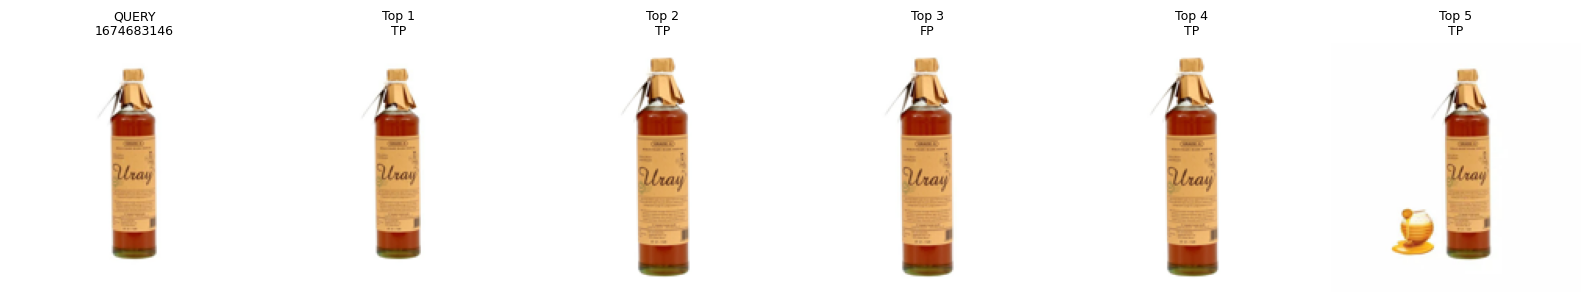

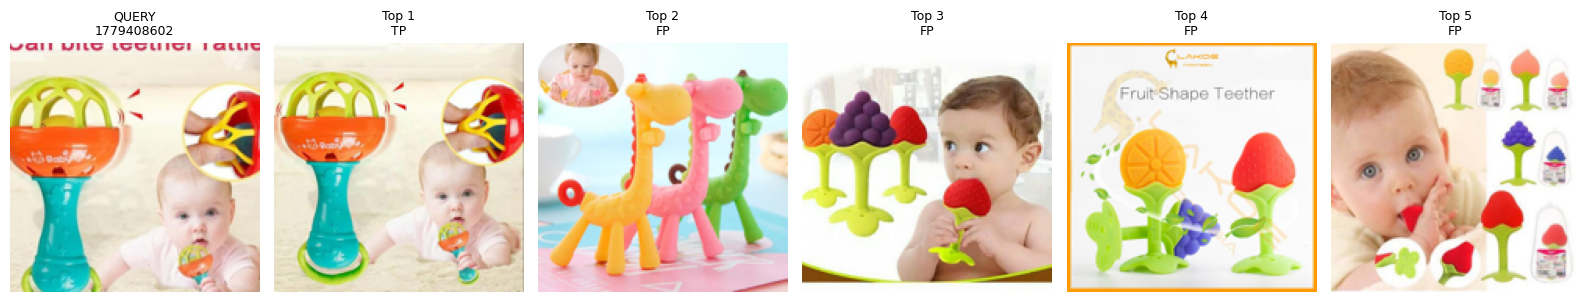

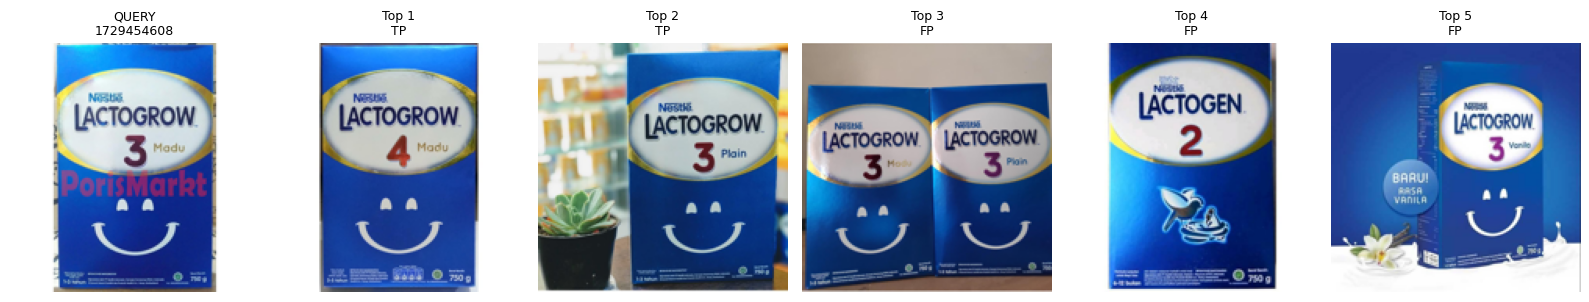

In [91]:
import matplotlib.pyplot as plt

best_top = top_by_key[best_run_key]


def load_image_safe(path, size=(160, 160)):
    try:
        return Image.open(path).convert('RGB').resize(size)
    except Exception:
        return Image.new('RGB', size, color=(255, 255, 255))


def visualize_query(q_idx):
    top = best_top[q_idx][:5]
    q_label = labels[q_idx]

    fig, axes = plt.subplots(1, 6, figsize=(16, 3))

    # Query
    axes[0].imshow(load_image_safe(candidate_df.loc[q_idx, 'image_path']))
    axes[0].set_title('QUERY\n' + str(q_label), fontsize=9)
    axes[0].axis('off')

    for rank, idx in enumerate(top, start=1):
        axes[rank].imshow(load_image_safe(candidate_df.loc[idx, 'image_path']))
        ok = labels[idx] == q_label
        axes[rank].set_title(f'Top {rank}\n' + ('TP' if ok else 'FP'), fontsize=9)
        axes[rank].axis('off')

    plt.tight_layout()
    plt.show()

# Hiển thị 3 query mẫu
sample_indices = np.random.default_rng(SEED).choice(len(candidate_df), size=min(3, len(candidate_df)), replace=False)
for q in sample_indices:
    visualize_query(int(q))

## CELL 12: Nhận xét để đưa vào báo cáo

Mẫu nhận xét:

```text
Sau các thử nghiệm baseline và fusion, nhóm chọn phương pháp cuối cùng là score-level fusion giữa ResNet50 và TF-IDF, kết hợp pHash boost và candidate reranking.

Cụ thể, hệ thống lấy Top-100 candidate từ đặc trưng ảnh ResNet50 và Top-100 candidate từ đặc trưng văn bản TF-IDF. Hai tập candidate được gộp lại, sau đó xếp hạng lại bằng công thức:

final_score = 0.76 * image_score + 0.24 * text_score + phash_bonus

Trong đó, pHash boost được dùng để ưu tiên các ảnh có image_phash giống hoặc gần giống, giúp cải thiện khả năng nhận diện ảnh gần trùng trong bộ dữ liệu Shopee.

Cấu hình tốt nhất:
- alpha = 0.76
- pHash config = strong
- candidate_k = 100

Kết quả thực nghiệm tốt nhất:
- mAP@5 ≈ 0.7635
- Precision@1 ≈ 0.7909
- Precision@5 ≈ 0.4375
- Recall@10 ≈ 0.8317

Kết quả này cho thấy score-level fusion hiệu quả hơn so với nối vector trực tiếp, đồng thời pHash boost giúp cải thiện thêm metric ở các ảnh gần trùng hoặc ảnh sản phẩm có bố cục tương tự.
```
